# 第六章 &nbsp; &nbsp; 与学习相关的技巧
本章将介绍神经网络的学习中的一些重要观点，主题涉及寻找最优权重参数的最优化方法、权重参数的初始值、超参数的设定方法等。此外，为了应对过拟合，本章还将介绍权值衰减、Dropout等正则化方法，并进行实现。最后将对近年来众多研究中使用的Batch Normalization方法进行简单的介绍。使用本章介绍的方法，可以高效地进行神经网络（深度学习）的学习，提高识别精度。让我们一起往下看吧！

神经网络的学习的目的是找到使损失函数的值尽可能小的参数。这是寻找最优参数的问题，解决这个问题的过程称为最优化（optimization）。遗憾的是，神经网络的最优化问题非常难。这是因为参数空间非常复杂，无法轻易找到最优解（无法使用那种通过解数学式一下子就求得最小值的方法）。而且，在深度神经网络中，参数的数量非常庞大，导致最优化问题更加复杂。

在前几章中，为了找到最优参数，我们将参数的梯度（导数）作为了线索。使用参数的梯度，沿梯度方向更新参数，并重复这个步骤多次，从而逐渐靠近最优参数，这个过程称为随机梯度下降法（stochastic gradient descent），简称SGD。SGD是一个简单的方法，不过比起胡乱地搜索参数空间，也算是“聪明”的方法。但是，根据不同的问题，也存在比SGD更加聪明的方法。本节我们将指出SGD的缺点，并介绍SGD以外的其他最优化方法。

## SGD
用数学式可以将SGD写成如下的式(6.1)。

$$
\boldsymbol{W} \leftarrow \boldsymbol{W} - \eta \frac{\partial L}{\partial \boldsymbol{W}} \tag{6.1}
$$

这里把需要更新的权重参数记为$\boldsymbol{W}$，把损失函数关于$\boldsymbol{W}$的梯度记为$\frac{\partial L}{\partial \boldsymbol{W}}$。$\eta$表示学习率，实际上会取0.01或0.001这些事先决定好的值。式子中的$\leftarrow$表示用右边的值更新左边的值。如式(6.1)所示，SGD是朝着梯度方向只前进一定距离的简单方法。现在，我们将SGD实现为一个Python类（为方便后面使用，我们将其实现为一个名为SGD的类）。


<img src="./fig/sgd.png" alt="SGD" style="display: block; margin: 0 auto;">

In [1]:
class SGD:
    def __init__(self, lr=0.01):
        self.lr = lr

    def update(self, params, grads):
        for key in params.keys():  # params.keys()返回params的所有key
            params[key] -= self.lr * grads[key] # SGD的参数更新公式

这里，进行初始化时的参数`lr`表示learning rate(学习率)。这个学习率会保存为实例变量。此外，代码段中还定义了`update(params, grads)`方法，这个方法在SGD中会被反复调用。参数`params`和`grads`（与之前的神经网络的实现一样）是字典型变量，按`params['W1']`、`grads['W1']`的形式，分别保存了权重参数和它们的梯度。

使用这个SGD类，可以按如下方式进行神经网络的参数的更新（下面的代码是不能实际运行的伪代码）。

```python
network = TwoLayerNet(...)
optimizer = SGD()

for i in range(10000):
    ...
    x_batch, t_batch = get_mini_batch(...) # mini-batch
    grads = network.gradient(x_batch, t_batch)
    params = network.params
    optimizer.update(params, grads)
    ...
```

这里首次出现的变量名`optimizer`表示“进行最优化的人”的意思，这里由SGD承担这个角色。参数的更新由`optimizer`负责完成。我们在这里需要做的只是将参数和梯度的信息传给`optimizer`。

像这样，通过单独实现进行最优化的类，功能的模块化变得更简单。比如，后面我们马上会实现另一个最优化方法Momentum，它同样会实现成拥有`update(params, grads)`这个共同方法的形式。这样一来，只需要将`optimizer = SGD()`这一语句换成`optimizer = Momentum()`，就可以从SGD切换为Momentum。

## Momentum
Momentum是“动量”的意思，和物理有关。用数学式表示Momentum方法，如下所示。

$$
\boldsymbol{v} \leftarrow \alpha \boldsymbol{v} - \eta \frac{\partial L}{\partial \boldsymbol{W}} \tag{6.3}
$$

$$
\boldsymbol{W} \leftarrow \boldsymbol{W} + \boldsymbol{v} \tag{6.4}
$$

和前面的SGD一样，$\boldsymbol{W}$表示要更新的权重参数，$\frac{\partial L}{\partial \boldsymbol{W}}$表示损失函数关于$\boldsymbol{W}$的梯度，$\eta$表示学习率。这里新出现了一个变量$\boldsymbol{v}$，对应物理上的速度。式(6.3)表示了物体在梯度方向上受力，在这个力的作用下，物体的速度增加这一物理法则。如图6-4所示，Momentum方法给人的感觉就像是小球在地面上滚动。

式(6.3)中有 $\alpha \boldsymbol{v}$ 这一项。在物体不受任何力时，该项承担使物体逐渐减速的任务（$\alpha$ 设定为0.9之类的值），对应物理上的地面摩擦或空气阻力，下面是Momentum的代码实现。

<img src="./fig/momentum.png" alt="Momentum" style="display: block; margin: 0 auto;">

In [2]:
import numpy as np

class Momentum:
    def __init__(self, lr=0.01, momentum=0.9):
        self.lr = lr
        self.momentum = momentum 
        self.v = None

    def update(self, params, grads):
        if self.v is None:
            self.v = {}
            for key, val in params.items(): # params.items()返回params的所有key和value
                self.v[key] = np.zeros_like(val) # 初始化为0

            # 更新参数
            for key in params.keys(): # params.keys()返回params的所有key
                self.v[key] = self.momentum * self.v[key] - self.lr * grads[key]
                params[key] += self.v[key]


## AdaGrad

在神经网络的学习中，学习率（数学式中记为$\eta$）的值很重要。学习率过小，会导致学习花费过多时间；反过来，学习率过大，则会导致学习发散而不能正确进行。

在关于学习率的有效技巧中，有一种被称为**学习率衰减**(learning rate decay)的方法，即随着学习的进行，使学习率逐渐减小。实际上，一开始“多”学，然后逐渐“少”学的方法，在神经网络的学习中经常被使用。

逐渐减小学习率的想法，相当于将“全体”参数的学习率值一起降低。而AdaGrad进一步发展了这个想法，针对“一个一个”的参数，赋予其“定制”的值。

AdaGrad会为参数的每个元素适当地调整学习率，与此同时进行学习（AdaGrad的Ada来自英文单词Adaptive，即“适当的”的意思）。下面，让我们用数学式表示AdaGrad的更新方法。

$$
\boldsymbol{h} \leftarrow \boldsymbol{h} + \frac{\partial L}{\partial \boldsymbol{W}} \odot \frac{\partial L}{\partial \boldsymbol{W}} \tag{6.5}
$$

$$
\boldsymbol{W} \leftarrow \boldsymbol{W} - \eta \frac{1}{\sqrt{\boldsymbol{h}}} \frac{\partial L}{\partial \boldsymbol{W}} \tag{6.6}
$$

和前面的SGD一样，$\boldsymbol{W}$表示要更新的权重参数，$\frac{\partial L}{\partial \boldsymbol{W}}$表示损失函数关于$\boldsymbol{W}$的梯度，$\eta$表示学习率。这里新出现了变量$\boldsymbol{h}$，如式(6.5)所示，它保存了以前的所有梯度值的平方和（式(6.5)中的$\odot$表示对应矩阵元素的乘法）。然后，在更新参数时，通过乘以$\frac{1}{\sqrt{\boldsymbol{h}}}$，就可以调整学习的尺度。这意味着，参数的元素中变动较大（被大幅更新）的元素的学习率将变小。也就是说，可以按参数的元素进行学习率衰减，使变动大的参数的学习率逐渐减小。

AdaGrad会记录过去所有梯度的平方和。因此，学习越深入，更新的幅度就越小。实际上，如果无止境地学习，更新量就会变为0，完全不再更新。为了改善这个问题，可以使用RMSProp方法。RMSProp方法并不是将过去所有的梯度一视同仁地相加，而是逐渐地遗忘过去的梯度，在做加法运算时将新梯度的信息更多地反映出来。这种操作从专业上讲，称为“指数移动平均”，呈指数函数式地减小过去的梯度的尺度。

现在来实现AdaGrad，AdaGrad的实现过程如下所示。

<img src="./fig/adagrad.png" alt="AdaGrad" style="display: block; margin: 0 auto;">

In [3]:
class AdaGrad:
    def __init__(self, lr=0.01):
        self.lr = lr
        self.h =None # 累积的梯度平方和

    def update(self, params, grads):
        if self.h is None:
            self.h = {}
            for key, val in params.items(): # params.items()返回params的所有key和value
                self.h[key] = np.zeros_like(val) # 初始化为0

            for key in params.keys(): # params.keys()返回params的所有key
                self.h[key] += grads[key] * grads[key] # 累积梯度平方
                params[key] -= self.lr * grads[key] / (np.sqrt(self.h[key]) + 1e-7) # 防止除0，1e-7是一个很小的数

## Adam

Momentum参照小球在碗中滚动的物理规则进行移动，AdaGrad为参数的每个元素适当地调整更新步伐。如果将这两个方法融合在一起会怎么样呢？这就是Adam方法的基本思路 ①。

Adam是2015年提出的新方法。它的理论有些复杂，直观地讲，就是融合了Momentum和AdaGrad的方法。通过组合前面两个方法的优点，有望实现参数空间的高效搜索。此外，进行超参数的“偏置校正”也是Adam的特征。这里不再进行过多的说明，详细内容请参考原作者的论文。关于Python的实现，`common/optimizer.py`中将其实现为了`Adam`类，有兴趣的读者可以参考。

Adam会设置3个超参数。一个是学习率（论文中以$\alpha$出现），另外两个是一次momentum系数$\beta_1$和二次momentum系数$\beta_2$。根据论文，标准的设定值是$\beta_1$为0.9，$\beta_2$为0.999。设置了这些值后，大多数情况下都能顺利运行。

<img src="./fig/adam.png" alt="Adam" style="display: block; margin: 0 auto;">

In [4]:
class Adam:

    def __init__(self, lr=0.001, beta1=0.9, beta2=0.999):
        self.lr = lr
        self.beta1 = beta1
        self.beta2 = beta2
        self.iter = 0
        self.m = None
        self.v = None
        
    def update(self, params, grads):
        if self.m is None:
            self.m, self.v = {}, {}
            for key, val in params.items():
                self.m[key] = np.zeros_like(val)
                self.v[key] = np.zeros_like(val)
        
        self.iter += 1 # 迭代次数
        lr_t  = self.lr * np.sqrt(1.0 - self.beta2**self.iter) / (1.0 - self.beta1**self.iter) # 学习率的修正    
        
        for key in params.keys():
            self.m[key] += (1 - self.beta1) * (grads[key] - self.m[key]) # 一阶矩估计
            self.v[key] += (1 - self.beta2) * (grads[key]**2 - self.v[key]) # 二阶矩估计
            # 参数更新
            params[key] -= lr_t * self.m[key] / (np.sqrt(self.v[key]) + 1e-7)

===========iteration:0===========
SGD:2.2950901317556784
Momentum:2.4622029051245917
AdaGrad:2.124218626125718
Adam:2.1832405948989067
===========iteration:100===========
SGD:1.871106623827488
Momentum:0.3238023013659478
AdaGrad:0.15128808451070458
Adam:0.3039750293460501
===========iteration:200===========
SGD:1.0630511246104386
Momentum:0.3017799656036798
AdaGrad:0.1674127171713535
Adam:0.26992846367292755
===========iteration:300===========
SGD:0.5197881393720845
Momentum:0.1562962342185862
AdaGrad:0.07625023499428463
Adam:0.1348980507386128
===========iteration:400===========
SGD:0.4537509852139069
Momentum:0.16845562697491928
AdaGrad:0.06271761885900687
Adam:0.09519135827420372
===========iteration:500===========
SGD:0.3257549288237936
Momentum:0.138064305029811
AdaGrad:0.034009107629874545
Adam:0.05523580281685994
===========iteration:600===========
SGD:0.3534753039528632
Momentum:0.08240041572520813
AdaGrad:0.04946255913258596
Adam:0.048246045530942916
===========iteration:700==

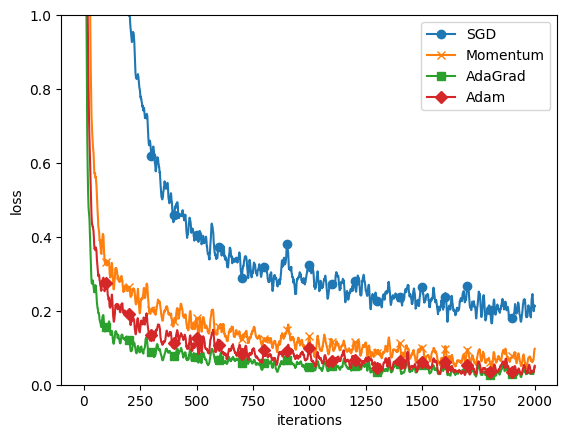

In [5]:
import os
import sys
sys.path.append(os.pardir)  # 为了导入父目录的文件而进行的设定
import matplotlib.pyplot as plt
from dataset.mnist import load_mnist
from common.util import smooth_curve
from common.multi_layer_net import MultiLayerNet
from common.optimizer import *


# 0:读入MNIST数据==========
(x_train, t_train), (x_test, t_test) = load_mnist(normalize=True)

train_size = x_train.shape[0]
batch_size = 128
max_iterations = 2000


# 1:进行实验的设置==========
optimizers = {}
optimizers['SGD'] = SGD()
optimizers['Momentum'] = Momentum()
optimizers['AdaGrad'] = AdaGrad()
optimizers['Adam'] = Adam()
# optimizers['RMSprop'] = RMSprop()

networks = {}
train_loss = {}
for key in optimizers.keys():
    networks[key] = MultiLayerNet(
        input_size=784, hidden_size_list=[100, 100, 100, 100],
        output_size=10)
    train_loss[key] = []    


# 2:开始训练==========
for i in range(max_iterations):
    batch_mask = np.random.choice(train_size, batch_size)
    x_batch = x_train[batch_mask]
    t_batch = t_train[batch_mask]
    
    for key in optimizers.keys():
        grads = networks[key].gradient(x_batch, t_batch) # 计算梯度
        optimizers[key].update(networks[key].params, grads) # 更新参数
    
        loss = networks[key].loss(x_batch, t_batch) # 计算损失函数
        train_loss[key].append(loss) # 记录损失函数的值
    
    if i % 100 == 0:
        print( "===========" + "iteration:" + str(i) + "===========")
        for key in optimizers.keys():
            loss = networks[key].loss(x_batch, t_batch)
            print(key + ":" + str(loss))


# 3.绘制图形==========
markers = {"SGD": "o", "Momentum": "x", "AdaGrad": "s", "Adam": "D"}
x = np.arange(max_iterations)
for key in optimizers.keys():
    plt.plot(x, smooth_curve(train_loss[key]), marker=markers[key], markevery=100, label=key)
plt.xlabel("iterations")
plt.ylabel("loss")
plt.ylim(0, 1)
plt.legend()
plt.show()

## 权重的初始值

在神经网络的学习中，权重的初始值特别重要。实际上，设定什么样的权重初始值，经常关系到神经网络的学习能否成功。本节将介绍权重初始值的推荐值，并通过实验确认神经网络的学习是否会快速进行。

后面我们会介绍抑制过拟合、提高泛化能力的技巧——**权重衰减**(weight decay)。简单地说，权重衰减就是一种以减小权重参数的值为目的进行学习的方法。通过减小权重参数的值来抑制过拟合的发生。

如果想减小权重的值，一开始就将初始值设为较小的值才是正途。实际上，在这之前的权重初始值都是像`0.01 * np.random.randn(10, 100)`这样，使用由高斯分布生成的值乘以0.01后得到的值（标准差为0.01的高斯分布）。

如果我们把权重初始值全部设为0以减小权重的值，会怎么样呢？从结论来说，将权重初始值设为0不是一个好主意。事实上，将权重初始值设为0的话，将无法正确进行学习。

为什么不能将权重初始值设为0呢？严格地说，为什么不能将权重初始值设成一样的值呢？这是因为在误差反向传播法中，所有的权重值都会进行相同的更新。比如，在2层神经网络中，假设第1层和第2层的权重为0。这样一来，正向传播时，因为输入层的权重为0，所以第2层的神经元全部会被传递相同的值。第2层的神经元中全部输入相同的值，这意味着反向传播时第2层的权重全部都会进行相同的更新（回忆一下“乘法节点的反向传播”的内容）。因此，权重被更新为相同的值，并拥有了对称的值（重复的值）。这使得神经网络拥有许多不同的权重的意义丧失了。为了防止“权重均一化”（严格地讲，是为了瓦解权重的对称结构），必须随机生成初始值。

## 隐藏层的激活值的分布

观察隐藏层的激活值（激活函数的输出数据）的分布，可以获得很多启发。这里，我们来做一个简单的实验，观察权重初始值是如何影响隐藏层的激活值的分布的。这里要做的实验是，向一个5层神经网络（激活函数使用sigmoid函数）传入随机生成的输入数据，用直方图绘制各层激活值的数据分布。这个实验参考了斯坦福大学的课程CS231n。

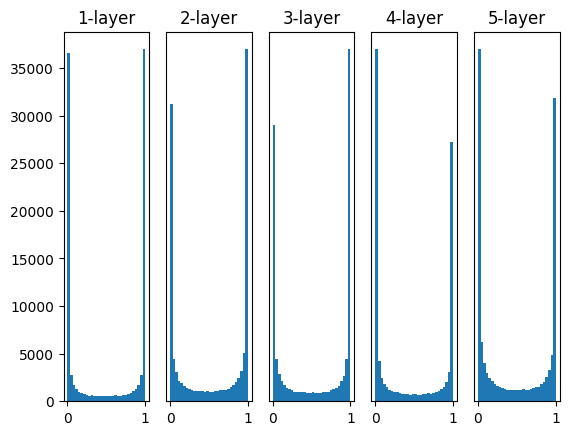

In [6]:
import numpy as np
import matplotlib.pyplot as plt

def sigmoid(x):
    return 1 / (1 + np.exp(-x))


def ReLU(x):
    return np.maximum(0, x)


def tanh(x):
    return np.tanh(x)

x = np.random.randn(1000,100) # 1000个样本，每个样本100维
node_num = 100 # 各隐含层节点数
hidden_layer_size = 5 # 隐含层数
activations = {} # 保存各层的激活值

for i in range(hidden_layer_size):
    if i != 0:
        x = activations[i-1] # 前一层的输出作为输入

    # 改变初始值进行实验！
    w = np.random.randn(node_num, node_num) * 1
    # w = np.random.randn(node_num, node_num) * 0.01
    # w = np.random.randn(node_num, node_num) * np.sqrt(1.0 / node_num)
    # w = np.random.randn(node_num, node_num) * np.sqrt(2.0 / node_num)

    a = np.dot(x, w) # 矩阵乘法
    
    # 将激活函数的种类也改变，来进行实验！
    z = sigmoid(a)
    # z = ReLU(a)
    # z = tanh(a)

    activations[i] = z

# 绘制直方图
for i, a in activations.items():
    plt.subplot(1, len(activations), i+1)
    plt.title(str(i+1) + "-layer")
    if i != 0: plt.yticks([], [])
    # plt.xlim(0.1, 1)
    # plt.ylim(0, 7000)
    plt.hist(a.flatten(), 30, range=(0,1))
plt.show()

各层的激活值呈偏向0和1的分布。这里使用的sigmoid函数是S型函数，随着输出不断地靠近0（或者靠近1），它的导数的值逐渐接近0。因此，偏向0和1的数据分布会造成反向传播中梯度的值不断变小，最后消失。这个问题称为梯度消失（gradient vanishing）。层次加深的深度学习中，梯度消失的问题可能会更加严重。

下面，将权重的标准差设为0.01，进行相同的实验。实验的代码只需要把设定权重初始值的地方换成下面的代码即可。

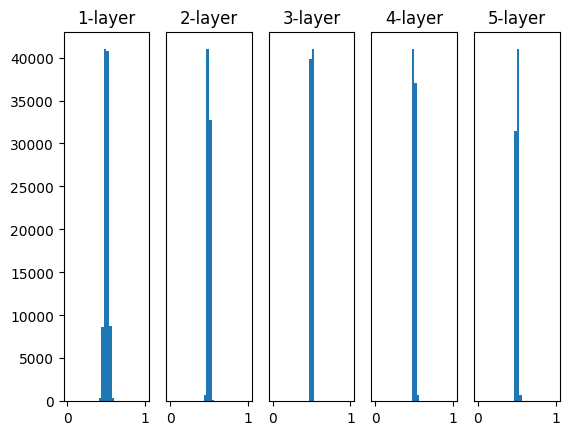

In [7]:
import numpy as np
import matplotlib.pyplot as plt

def sigmoid(x):
    return 1 / (1 + np.exp(-x))


def ReLU(x):
    return np.maximum(0, x)


def tanh(x):
    return np.tanh(x)

x = np.random.randn(1000,100) # 1000个样本，每个样本100维
node_num = 100 # 各隐含层节点数
hidden_layer_size = 5 # 隐含层数
activations = {} # 保存各层的激活值

for i in range(hidden_layer_size):
    if i != 0:
        x = activations[i-1] # 前一层的输出作为输入

    # 改变初始值进行实验！
    # w = np.random.randn(node_num, node_num) * 1
    w = np.random.randn(node_num, node_num) * 0.01
    # w = np.random.randn(node_num, node_num) * np.sqrt(1.0 / node_num)
    # w = np.random.randn(node_num, node_num) * np.sqrt(2.0 / node_num)

    a = np.dot(x, w) # 矩阵乘法
    
    # 将激活函数的种类也改变，来进行实验！
    z = sigmoid(a)
    # z = ReLU(a)
    # z = tanh(a)

    activations[i] = z

# 绘制直方图
for i, a in activations.items():
    plt.subplot(1, len(activations), i+1)
    plt.title(str(i+1) + "-layer")
    if i != 0: plt.yticks([], [])
    # plt.xlim(0.1, 1)
    # plt.ylim(0, 7000)
    plt.hist(a.flatten(), 30, range=(0,1))
plt.show()

这次呈集中在0.5附近的分布。因为不像刚才的例子那样偏向0和1，所以不会发生梯度消失的问题。但是，激活值的分布有所偏向，说明在表现力上会有很大问题。为什么这么说呢？因为如果有多个神经元都输出几乎相同的值，那它们就没有存在的意义了。比如，如果100个神经元都输出几乎相同的值，那么也可以由1个神经元来表达基本相同的事情。因此，激活值在分布上有所偏向会出现“表现力受限”的问题。

各层的激活值的分布都要求有适当的广度。为什么呢？因为通过在各层间传递多样性的数据，神经网络可以进行高效的学习。反过来，如果传递的是有所偏向的数据，就会出现梯度消失或者“表现力受限”的问题，导致学习可能无法顺利进行。

接着，我们尝试使用Xavier Glorot等人的论文中推荐的权重初始值（俗称 “Xavier初始值”）。现在，在一般的深度学习框架中，Xavier 初始值已被作为标准使用。比如，Caffe框架中，通过在设定权重初始值时赋予xavier参数，就可以使用Xavier初始值。

Xavier的论文中，为了使各层的激活值呈现出具有相同广度的分布，推导了合适的权重尺度。推导出的结论是，如果前一层的节点数为$n$，则初始值使用标准差为$\frac{1}{\sqrt{n}}$的分布。

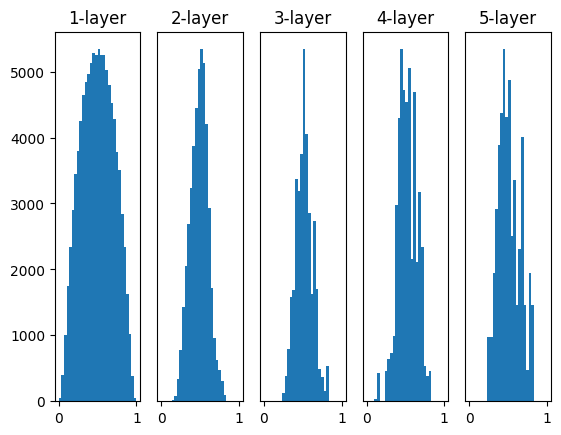

In [8]:
import numpy as np
import matplotlib.pyplot as plt

def sigmoid(x):
    return 1 / (1 + np.exp(-x))


def ReLU(x):
    return np.maximum(0, x)


def tanh(x):
    return np.tanh(x)

x = np.random.randn(1000,100) # 1000个样本，每个样本100维
node_num = 100 # 各隐含层节点数
hidden_layer_size = 5 # 隐含层数
activations = {} # 保存各层的激活值

for i in range(hidden_layer_size):
    if i != 0:
        x = activations[i-1] # 前一层的输出作为输入

    # 改变初始值进行实验！
    # w = np.random.randn(node_num, node_num) * 1
    # w = np.random.randn(node_num, node_num) * 0.01
    w = np.random.randn(node_num, node_num) * np.sqrt(1.0 / node_num)
    # w = np.random.randn(node_num, node_num) * np.sqrt(2.0 / node_num)

    a = np.dot(x, w) # 矩阵乘法
    
    # 将激活函数的种类也改变，来进行实验！
    z = sigmoid(a)
    # z = ReLU(a)
    # z = tanh(a)

    activations[i] = z

# 绘制直方图
for i, a in activations.items():
    plt.subplot(1, len(activations), i+1)
    plt.title(str(i+1) + "-layer")
    if i != 0: plt.yticks([], [])
    # plt.xlim(0.1, 1)
    # plt.ylim(0, 7000)
    plt.hist(a.flatten(), 30, range=(0,1))
plt.show()

从这个结果可知，越是后面的层，图像变得越歪斜，但是呈现了比之前更有广度的分布。因为各层间传递的数据有适当的广度，所以sigmoid函数的表现力不受限制，有望进行高效的学习。

## ReLU的权重初始值
Xavier初始值是以激活函数是线性函数为前提而推导出来的。因为sigmoid函数和tanh函数左右对称，且中央附近可以视作线性函数，所以适合使用Xavier初始值。但当激活函数使用ReLU时，一般推荐使用ReLU专用的初始值，也就是Kaiming He等人推荐的初始值，也称为 “He初始值”。当前一层的节点数为$n$时，He初始值使用标准差为$\sqrt{\frac{2}{n}}$的高斯分布。当Xavier初始值是$\sqrt{\frac{1}{n}}$时，(直观上)可以解释为，因为ReLU的负值区域的值为0，为了使它更有广度，所以需要2倍的系数。

现在来看一下激活函数使用ReLU时激活值的分布。我们给出了3个实验的结果，依次是权重初始值为标准差是0.01的高斯分布(下文简写为 “std = 0.01”)时、初始值为Xavier初始值时、初始值为ReLU专用的“He初始值”时的结果。

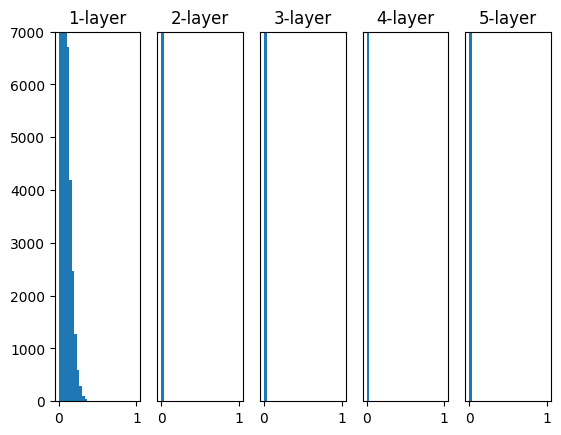

In [9]:
import numpy as np
import matplotlib.pyplot as plt

def sigmoid(x):
    return 1 / (1 + np.exp(-x))


def ReLU(x):
    return np.maximum(0, x)


def tanh(x):
    return np.tanh(x)

x = np.random.randn(1000,100) # 1000个样本，每个样本100维
node_num = 100 # 各隐含层节点数
hidden_layer_size = 5 # 隐含层数
activations = {} # 保存各层的激活值

for i in range(hidden_layer_size):
    if i != 0:
        x = activations[i-1] # 前一层的输出作为输入

    # 改变初始值进行实验！
    # w = np.random.randn(node_num, node_num) * 1
    w = np.random.randn(node_num, node_num) * 0.01
    # w = np.random.randn(node_num, node_num) * np.sqrt(1.0 / node_num)
    # w = np.random.randn(node_num, node_num) * np.sqrt(2.0 / node_num)

    a = np.dot(x, w) # 矩阵乘法
    
    # 将激活函数的种类也改变，来进行实验！
    # z = sigmoid(a)
    z = ReLU(a)
    # z = tanh(a)

    activations[i] = z

# 绘制直方图
for i, a in activations.items():
    plt.subplot(1, len(activations), i+1)
    plt.title(str(i+1) + "-layer")
    if i != 0: plt.yticks([], [])
    # plt.xlim(0.1, 1)
    plt.ylim(0, 7000)
    plt.hist(a.flatten(), 30, range=(0,1))
plt.show()

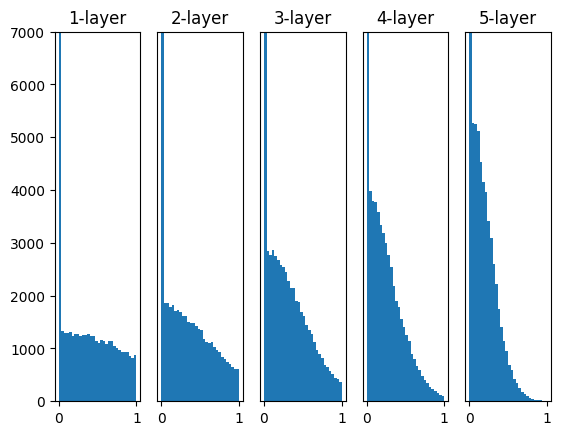

In [10]:
import numpy as np
import matplotlib.pyplot as plt

def sigmoid(x):
    return 1 / (1 + np.exp(-x))


def ReLU(x):
    return np.maximum(0, x)


def tanh(x):
    return np.tanh(x)

x = np.random.randn(1000,100) # 1000个样本，每个样本100维
node_num = 100 # 各隐含层节点数
hidden_layer_size = 5 # 隐含层数
activations = {} # 保存各层的激活值

for i in range(hidden_layer_size):
    if i != 0:
        x = activations[i-1] # 前一层的输出作为输入

    # 改变初始值进行实验！
    # w = np.random.randn(node_num, node_num) * 1
    # w = np.random.randn(node_num, node_num) * 0.01
    w = np.random.randn(node_num, node_num) * np.sqrt(1.0 / node_num)
    # w = np.random.randn(node_num, node_num) * np.sqrt(2.0 / node_num)

    a = np.dot(x, w) # 矩阵乘法
    
    # 将激活函数的种类也改变，来进行实验！
    # z = sigmoid(a)
    z = ReLU(a)
    # z = tanh(a)

    activations[i] = z

# 绘制直方图
for i, a in activations.items():
    plt.subplot(1, len(activations), i+1)
    plt.title(str(i+1) + "-layer")
    if i != 0: plt.yticks([], [])
    # plt.xlim(0.1, 1)
    plt.ylim(0, 7000)
    plt.hist(a.flatten(), 30, range=(0,1))
plt.show()

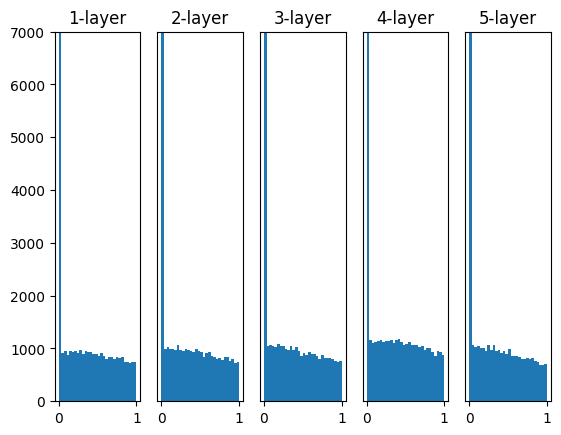

In [11]:
import numpy as np
import matplotlib.pyplot as plt

def sigmoid(x):
    return 1 / (1 + np.exp(-x))


def ReLU(x):
    return np.maximum(0, x)


def tanh(x):
    return np.tanh(x)

x = np.random.randn(1000,100) # 1000个样本，每个样本100维
node_num = 100 # 各隐含层节点数
hidden_layer_size = 5 # 隐含层数
activations = {} # 保存各层的激活值

for i in range(hidden_layer_size):
    if i != 0:
        x = activations[i-1] # 前一层的输出作为输入

    # 改变初始值进行实验！
    # w = np.random.randn(node_num, node_num) * 1
    # w = np.random.randn(node_num, node_num) * 0.01
    # w = np.random.randn(node_num, node_num) * np.sqrt(1.0 / node_num)
    w = np.random.randn(node_num, node_num) * np.sqrt(2.0 / node_num)

    a = np.dot(x, w) # 矩阵乘法
    
    # 将激活函数的种类也改变，来进行实验！
    # z = sigmoid(a)
    z = ReLU(a)
    # z = tanh(a)

    activations[i] = z

# 绘制直方图
for i, a in activations.items():
    plt.subplot(1, len(activations), i+1)
    plt.title(str(i+1) + "-layer")
    if i != 0: plt.yticks([], [])
    # plt.xlim(0.1, 1)
    plt.ylim(0, 7000)
    plt.hist(a.flatten(), 30, range=(0,1))
plt.show()

观察实验结果可知，当 “std = 0.01” 时，各层的激活值非常小。神经网络上传递的是非常小的值，说明逆向传播时权重的梯度也同样很小。这是很严重的问题，实际上学习基本上没有进展。

接下来是初始值为Xavier初始值时的结果。在这种情况下，随着层的加深，偏向一点点变大。实际上，层加深后，激活值的偏向变大，学习时会出现梯度消失的问题。而当初始值为He初始值时，各层中分布的广度相同。由于即便层加深，数据的广度也能保持不变，因此逆向传播时，也会传递合适的值。

总结一下，当激活函数使用ReLU时，权重初始值使用He初始值，当激活函数为sigmoid或tanh等S型曲线函数时，初始值使用Xavier初始值。这是目前的最佳实践。

## 基于MNIST数据集的权重初始值的比较
下面通过实际的数据，观察不同的权重初始值的赋值方法会在多大程度上影响神经网络的学习。这里，我们基于std = 0.01、Xavier初始值、He初始值进行实验。

===========iteration:0===========
std=0.01:2.3025314780263315
Xavier:2.300364680453387
He:2.3486070114872404
===========iteration:100===========
std=0.01:2.3025851840949594
Xavier:2.245752933431553
He:1.5416449892571653
===========iteration:200===========
std=0.01:2.3018832855695734
Xavier:2.1117687205347413
He:0.7874175168568882
===========iteration:300===========
std=0.01:2.3051705561114564
Xavier:1.825514329009459
He:0.5694948556989792
===========iteration:400===========
std=0.01:2.3007527989438525
Xavier:1.2345934657935436
He:0.46781507038032183
===========iteration:500===========
std=0.01:2.3038544945993458
Xavier:0.8790341117227191
He:0.4012864447577458
===========iteration:600===========
std=0.01:2.2987461765472283
Xavier:0.5655867584230547
He:0.2503647249073057
===========iteration:700===========
std=0.01:2.303396904224601
Xavier:0.5330119704799832
He:0.2949214853162796
===========iteration:800===========
std=0.01:2.3011417946345976
Xavier:0.44065609813773066
He:0.2461013516578

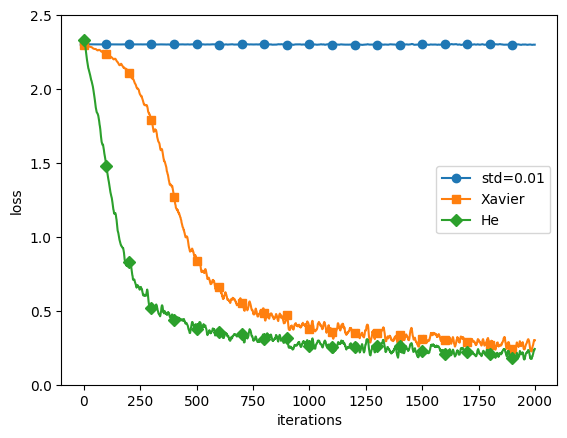

In [12]:
import os
import sys
sys.path.append(os.pardir)  # 为了导入父目录的文件而进行的设定
import numpy as np
import matplotlib.pyplot as plt
from dataset.mnist import load_mnist
from common.util import smooth_curve
from common.multi_layer_net import MultiLayerNet
from common.optimizer import SGD


# 0:读入MNIST数据==========
(x_train, t_train), (x_test, t_test) = load_mnist(normalize=True)

train_size = x_train.shape[0]
batch_size = 128
max_iterations = 2000


# 1:进行实验的设置==========
weight_init_types = {'std=0.01': 0.01, 'Xavier': 'sigmoid', 'He': 'relu'}
optimizer = SGD(lr=0.01)

networks = {}
train_loss = {}
for key, weight_type in weight_init_types.items():
    networks[key] = MultiLayerNet(input_size=784, hidden_size_list=[100, 100, 100, 100],
                                  output_size=10, weight_init_std=weight_type)
    train_loss[key] = []


# 2:开始训练==========
for i in range(max_iterations):
    batch_mask = np.random.choice(train_size, batch_size)
    x_batch = x_train[batch_mask]
    t_batch = t_train[batch_mask]
    
    for key in weight_init_types.keys():
        grads = networks[key].gradient(x_batch, t_batch)
        optimizer.update(networks[key].params, grads)
    
        loss = networks[key].loss(x_batch, t_batch)
        train_loss[key].append(loss)
    
    if i % 100 == 0:
        print("===========" + "iteration:" + str(i) + "===========")
        for key in weight_init_types.keys():
            loss = networks[key].loss(x_batch, t_batch)
            print(key + ":" + str(loss))


# 3.绘制图形==========
markers = {'std=0.01': 'o', 'Xavier': 's', 'He': 'D'}
x = np.arange(max_iterations)
for key in weight_init_types.keys():
    plt.plot(x, smooth_curve(train_loss[key]), marker=markers[key], markevery=100, label=key)
plt.xlabel("iterations")
plt.ylabel("loss")
plt.ylim(0, 2.5)
plt.legend()
plt.show()

这个实验中，神经网络有5层，每层有100个神经元，激活函数使用的是ReLU。从图的结果可知，std = 0.01时完全无法进行学习。这和刚才观察到的激活值的分布一样，是因为正向传播中传递的值很小（集中在0附近的数据）。因此，逆向传播时求到的梯度也很小，权重几乎不进行更新。相反，当权重初始值为Xavier初始值和He初始值时，学习进行得很顺利。并且，我们发现He初始值时的学习进度更快一些。

综上，在神经网络的学习中，权重初始值非常重要。很多时候权重初始值的设定关系到神经网络的学习能否成功。权重初始值的重要性容易被忽视，而任何事情的开始（初始值）总是关键的，因此在结束本节之际，再次强调一下权重初始值的重要性。

## Batch-Normalization算法
Batch Normalization（下文简称Batch Norm）是2015年提出的方法。Batch Norm虽然是一个问世不久的新方法，但已经被很多研究人员和技术人员广泛使用。实际上，看一下机器学习竞赛的结果，就会发现很多通过使用这个方法而获得优异结果的例子。

为什么Batch Norm这么惹人注目呢？因为Batch Norm有以下优点。
- 可以使学习快速进行（可以增大学习率）。
- 不那么依赖初始值（对于初始值不用那么神经质）。
- 抑制过拟合（降低Dropout等的必要性）。

考虑到深度学习要花费很多时间，第一个优点令人非常开心。另外，后两点也可以帮我们消除深度学习的学习中的很多烦恼。

如前所述，Batch Norm的思路是调整各层的激活值分布使其拥有适当的广度。为此，要向神经网络中插入对数据分布进行正规化的层，即Batch Normalization层（下文简称Batch Norm层），如图所示。

<img src="./fig/BN.png" alt="BN" style="display: block; margin: 0 auto;">

Batch Norm，顾名思义，以进行学习时的mini - batch为单位，按mini - batch进行正规化。具体而言，就是进行使数据分布的均值为0、方差为1的正规化。用数学式表示的话，如下所示。

$$
\mu_B \leftarrow \frac{1}{m}\sum_{i = 1}^{m}x_i
$$

$$
\sigma_B^2 \leftarrow \frac{1}{m}\sum_{i = 1}^{m}(x_i - \mu_B)^2 \tag{6.7}
$$

$$
\hat{x}_i \leftarrow \frac{x_i - \mu_B}{\sqrt{\sigma_B^2 + \varepsilon}}
$$

这里对mini - batch的$m$个输入数据的集合$B = \{x_1, x_2, \dots, x_m\}$求均值$\mu_B$和方差$\sigma_B^2$。然后，对输入数据进行均值为0、方差为1（合适的分布）的正规化。式(6.7)中的$\varepsilon$是一个微小值（比如，$10\text{e} - 7$等），它是为了防止出现除以0的情况。

式(6.7)所做的是将mini - batch的输入数据$\{x_1, x_2, \dots, x_m\}$变换为均值为0、方差为1的数据$\{\hat{x}_1, \hat{x}_2, \dots, \hat{x}_m\}$，非常简单。通过将这个处理插入到激活函数的前面（或者后面），可以减小数据分布的偏向。

接着，Batch Norm层会对正规化后的数据进行缩放和平移的变换，用数学式可以如下表示。

$$
y_i \leftarrow \gamma\hat{x}_i + \beta \tag{6.8}
$$

这里，$\gamma$和$\beta$是参数。一开始$\gamma = 1$，$\beta = 0$，然后再通过学习调整到合适的值。

## Batch-Normalization的评估
现在我们使用Batch Norm层进行实验。首先，使用MNIST数据集，观察使用Batch Norm层和不使用Batch Norm层时学习的过程会如何变化，结果如图所示。

============== 1/16 ==============
Epoch:   0 | 普通训练准确率: 0.0920 | BatchNorm训练准确率: 0.1040
Epoch:   1 | 普通训练准确率: 0.0970 | BatchNorm训练准确率: 0.1380


g:\计算机\python\python基于深度学习的基础编程\ch06与学习相关的技巧\..\common\functions.py:34: RuntimeWarning: invalid value encountered in subtract
  x = x - np.max(x, axis=0)


Epoch:   2 | 普通训练准确率: 0.0970 | BatchNorm训练准确率: 0.1640
Epoch:   3 | 普通训练准确率: 0.0970 | BatchNorm训练准确率: 0.1860
Epoch:   4 | 普通训练准确率: 0.0970 | BatchNorm训练准确率: 0.1980
Epoch:   5 | 普通训练准确率: 0.0970 | BatchNorm训练准确率: 0.2150
Epoch:   6 | 普通训练准确率: 0.0970 | BatchNorm训练准确率: 0.2260
Epoch:   7 | 普通训练准确率: 0.0970 | BatchNorm训练准确率: 0.2440
Epoch:   8 | 普通训练准确率: 0.0970 | BatchNorm训练准确率: 0.2550
Epoch:   9 | 普通训练准确率: 0.0970 | BatchNorm训练准确率: 0.2710
Epoch:  10 | 普通训练准确率: 0.0970 | BatchNorm训练准确率: 0.2890
Epoch:  11 | 普通训练准确率: 0.0970 | BatchNorm训练准确率: 0.3110
Epoch:  12 | 普通训练准确率: 0.0970 | BatchNorm训练准确率: 0.3230
Epoch:  13 | 普通训练准确率: 0.0970 | BatchNorm训练准确率: 0.3340
Epoch:  14 | 普通训练准确率: 0.0970 | BatchNorm训练准确率: 0.3460
Epoch:  15 | 普通训练准确率: 0.0970 | BatchNorm训练准确率: 0.3570
Epoch:  16 | 普通训练准确率: 0.0970 | BatchNorm训练准确率: 0.3730
Epoch:  17 | 普通训练准确率: 0.0970 | BatchNorm训练准确率: 0.3950
Epoch:  18 | 普通训练准确率: 0.0970 | BatchNorm训练准确率: 0.3990
Epoch:  19 | 普通训练准确率: 0.0970 | BatchNorm训练准确率: 0.4070
============== 2/16 ========

g:\计算机\python\python基于深度学习的基础编程\ch06与学习相关的技巧\..\common\multi_layer_net_extend.py:101: RuntimeWarning: overflow encountered in square
  weight_decay += 0.5 * self.weight_decay_lambda * np.sum(W**2)
g:\计算机\python\python基于深度学习的基础编程\ch06与学习相关的技巧\..\common\multi_layer_net_extend.py:101: RuntimeWarning: invalid value encountered in scalar multiply
  weight_decay += 0.5 * self.weight_decay_lambda * np.sum(W**2)


Epoch:   2 | 普通训练准确率: 0.0970 | BatchNorm训练准确率: 0.1620
Epoch:   3 | 普通训练准确率: 0.0970 | BatchNorm训练准确率: 0.1800
Epoch:   4 | 普通训练准确率: 0.0970 | BatchNorm训练准确率: 0.2070
Epoch:   5 | 普通训练准确率: 0.0970 | BatchNorm训练准确率: 0.2270
Epoch:   6 | 普通训练准确率: 0.0970 | BatchNorm训练准确率: 0.2690
Epoch:   7 | 普通训练准确率: 0.0970 | BatchNorm训练准确率: 0.2840
Epoch:   8 | 普通训练准确率: 0.0970 | BatchNorm训练准确率: 0.3060
Epoch:   9 | 普通训练准确率: 0.0970 | BatchNorm训练准确率: 0.3340
Epoch:  10 | 普通训练准确率: 0.0970 | BatchNorm训练准确率: 0.3610
Epoch:  11 | 普通训练准确率: 0.0970 | BatchNorm训练准确率: 0.3670
Epoch:  12 | 普通训练准确率: 0.0970 | BatchNorm训练准确率: 0.3870
Epoch:  13 | 普通训练准确率: 0.0970 | BatchNorm训练准确率: 0.4090
Epoch:  14 | 普通训练准确率: 0.0970 | BatchNorm训练准确率: 0.4310
Epoch:  15 | 普通训练准确率: 0.0970 | BatchNorm训练准确率: 0.4440
Epoch:  16 | 普通训练准确率: 0.0970 | BatchNorm训练准确率: 0.4610
Epoch:  17 | 普通训练准确率: 0.0970 | BatchNorm训练准确率: 0.4710
Epoch:  18 | 普通训练准确率: 0.0970 | BatchNorm训练准确率: 0.4940
Epoch:  19 | 普通训练准确率: 0.0970 | BatchNorm训练准确率: 0.5100
============== 3/16 ========

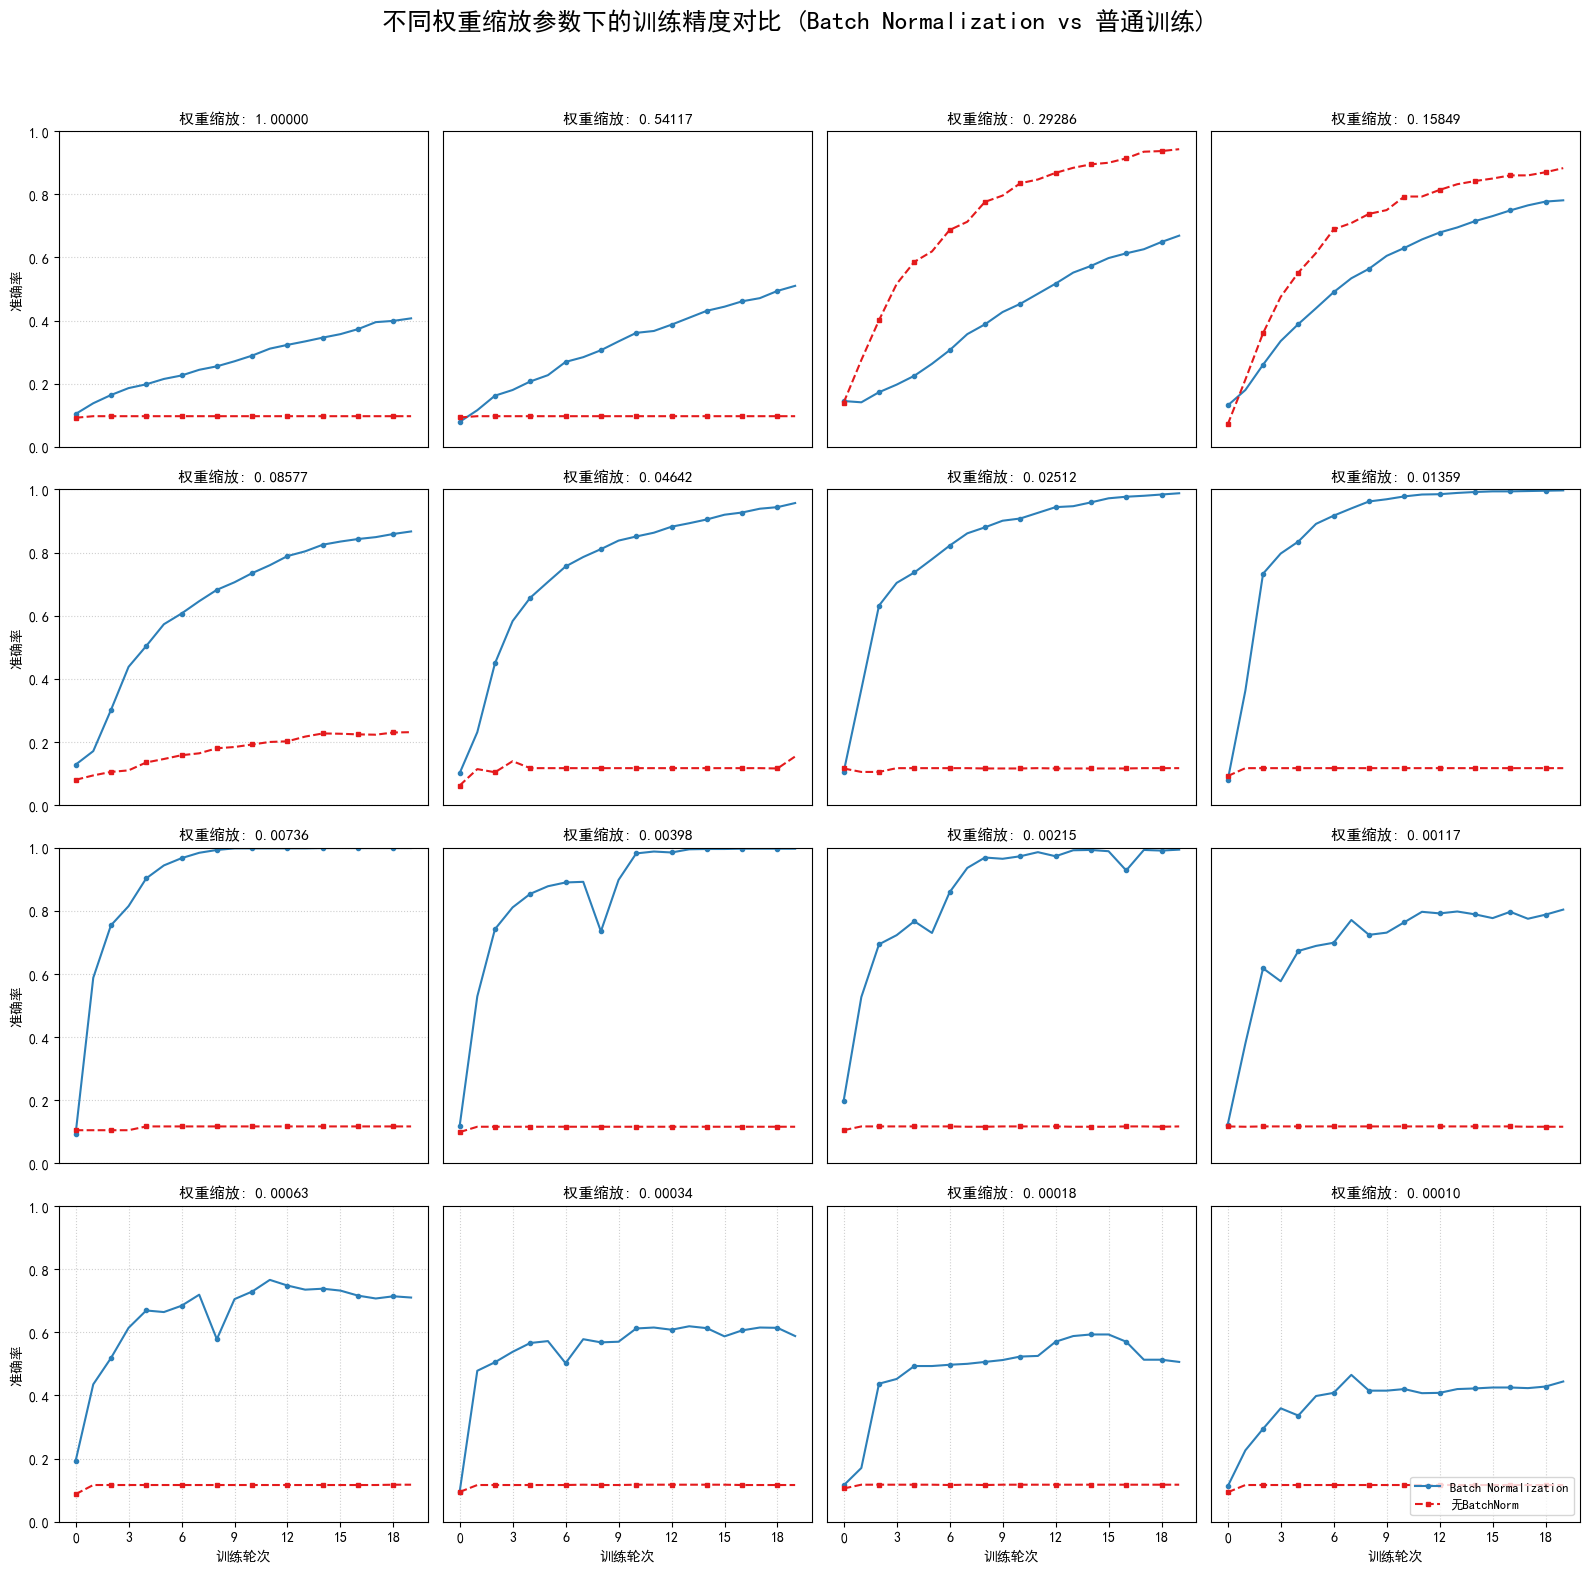

In [13]:
import sys, os
sys.path.append(os.pardir)  # 为了导入父目录的文件而进行的设定
import numpy as np
import matplotlib.pyplot as plt
from dataset.mnist import load_mnist
from common.multi_layer_net_extend import MultiLayerNetExtend
from common.optimizer import SGD, Adam
from matplotlib.ticker import MaxNLocator

plt.rcParams['font.sans-serif'] = ['SimHei']  # 设置中文黑体
plt.rcParams['axes.unicode_minus'] = False    # 正常显示负号

(x_train, t_train), (x_test, t_test) = load_mnist(normalize=True)

# 减少学习数据
x_train = x_train[:1000]
t_train = t_train[:1000]

max_epochs = 20
train_size = x_train.shape[0]
batch_size = 100
learning_rate = 0.01


def __train(weight_init_std):
    bn_network = MultiLayerNetExtend(input_size=784, hidden_size_list=[100, 100, 100, 100, 100], output_size=10, 
                                    weight_init_std=weight_init_std, use_batchnorm=True)
    network = MultiLayerNetExtend(input_size=784, hidden_size_list=[100, 100, 100, 100, 100], output_size=10,
                                weight_init_std=weight_init_std)
    optimizer = SGD(lr=learning_rate)
    
    train_acc_list = []
    bn_train_acc_list = []
    
    iter_per_epoch = max(train_size / batch_size, 1)
    epoch_cnt = 0
    
    for i in range(1000000000):
        batch_mask = np.random.choice(train_size, batch_size)
        x_batch = x_train[batch_mask]
        t_batch = t_train[batch_mask]
    
        for _network in (bn_network, network):
            grads = _network.gradient(x_batch, t_batch)
            optimizer.update(_network.params, grads)
    
        if i % iter_per_epoch == 0:
            train_acc = network.accuracy(x_train, t_train)
            bn_train_acc = bn_network.accuracy(x_train, t_train)
            train_acc_list.append(train_acc)
            bn_train_acc_list.append(bn_train_acc)
    
            print(f"Epoch: {epoch_cnt:3d} | 普通训练准确率: {train_acc:.4f} | BatchNorm训练准确率: {bn_train_acc:.4f}")
    
            epoch_cnt += 1
            if epoch_cnt >= max_epochs:
                break
                
    return train_acc_list, bn_train_acc_list


# 3.绘制图形==========
weight_scale_list = np.logspace(0, -4, num=16)
x = np.arange(max_epochs)

# 创建图形，调整大小
plt.figure(figsize=(16, 16))
# 调整子图间距
plt.subplots_adjust(left=0.06, right=0.98, bottom=0.06, top=0.92, wspace=0.15, hspace=0.2)

# 添加整体标题
plt.suptitle('不同权重缩放参数下的训练精度对比 (Batch Normalization vs 普通训练)', 
             fontsize=18, fontweight='bold')

for i, w in enumerate(weight_scale_list):
    print(f"============== {i+1}/16 ==============")
    train_acc_list, bn_train_acc_list = __train(w)
    
    plt.subplot(4, 4, i+1)
    # 美化标题格式，显示更清晰的权重值
    plt.title(f"权重缩放: {w:.5f}", fontsize=11, fontweight='medium')
    
    # 使用更美观的线条和标记样式
    plt.plot(x, bn_train_acc_list, label='Batch Normalization', 
             marker='o', markersize=3, markevery=2, linewidth=1.5, color='#2c7fb8')
    plt.plot(x, train_acc_list, linestyle="--", label='无BatchNorm', 
             marker='s', markersize=3, markevery=2, linewidth=1.5, color='#e41a1c')

    plt.ylim(0, 1.0)
    
    # 优化坐标轴显示
    if i % 4 != 0:
        plt.yticks([])
    else:
        plt.ylabel("准确率", fontsize=10)
    
    if i < 12:
        plt.xticks([])
    else:
        plt.xlabel("训练轮次", fontsize=10)
        # 确保x轴只显示整数
        plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True))
    
    # 只在最后一个子图显示图例，避免重复
    if i == 15:
        plt.legend(loc='lower right', fontsize=9)
    
    # 添加网格线，提高可读性
    plt.grid(True, linestyle=':', alpha=0.6)

# 调整布局并显示
plt.tight_layout(rect=[0, 0, 1, 0.95])  # 为总标题留出空间
plt.show()

从图的结果可知，使用Batch Norm后，学习进行得更快了。接着，给予不同的初始值尺度，观察学习的过程如何变化。图6-19是权重初始值的标准差为各种不同的值时的学习过程图。

我们发现，几乎所有的情况下都是使用Batch Norm时学习进行得更快。同时也可以发现，实际上，在不使用Batch Norm的情况下，如果不赋予一个尺度好的初始值，学习将完全无法进行。

综上，通过使用Batch Norm，可以推动学习的进行。并且，对权重初始值变得健壮（“对初始值健壮”表示不那么依赖初始值）。Batch Norm具备了如此优良的性质，一定能应用在更多场合中。

## 正则化 
机器学习的问题中，过拟合是一个很常见的问题。过拟合指的是只能拟合训练数据，但不能很好地拟合不包含在训练数据中的其他数据的状态。机器学习的目标是提高泛化能力，即便是没有包含在训练数据里的未观测数据，也希望模型可以进行正确的识别。我们可以制作复杂的、表现力强的模型，但是相应地，抑制过拟合的技巧也很重要。

### 过拟合
发生过拟合的原因，主要有以下两个。
- 模型拥有大量参数、表现力强。
- 训练数据少。

这里，我们故意满足这两个条件，制造过拟合现象。为此，要从MNIST数据集原本的60000个训练数据中只选定300个，并且，为了增加网络的复杂度，使用7层网络（每层有100个神经元，激活函数为ReLU）。

下面是用于实验的部分代码。

轮次:   0 | 训练准确率: 0.1400 | 测试准确率: 0.1164
轮次:   1 | 训练准确率: 0.1500 | 测试准确率: 0.1247
轮次:   2 | 训练准确率: 0.1633 | 测试准确率: 0.1302
轮次:   3 | 训练准确率: 0.1733 | 测试准确率: 0.1323
轮次:   4 | 训练准确率: 0.1933 | 测试准确率: 0.1424
轮次:   5 | 训练准确率: 0.2333 | 测试准确率: 0.1500
轮次:   6 | 训练准确率: 0.2533 | 测试准确率: 0.1590
轮次:   7 | 训练准确率: 0.2767 | 测试准确率: 0.1729
轮次:   8 | 训练准确率: 0.3033 | 测试准确率: 0.1946
轮次:   9 | 训练准确率: 0.3067 | 测试准确率: 0.2064
轮次:  10 | 训练准确率: 0.3300 | 测试准确率: 0.2248
轮次:  11 | 训练准确率: 0.3667 | 测试准确率: 0.2418
轮次:  12 | 训练准确率: 0.3667 | 测试准确率: 0.2511
轮次:  13 | 训练准确率: 0.3833 | 测试准确率: 0.2628
轮次:  14 | 训练准确率: 0.4133 | 测试准确率: 0.2754
轮次:  15 | 训练准确率: 0.4300 | 测试准确率: 0.2937
轮次:  16 | 训练准确率: 0.4433 | 测试准确率: 0.3029
轮次:  17 | 训练准确率: 0.4700 | 测试准确率: 0.3169
轮次:  18 | 训练准确率: 0.4867 | 测试准确率: 0.3325
轮次:  19 | 训练准确率: 0.4933 | 测试准确率: 0.3398
轮次:  20 | 训练准确率: 0.5267 | 测试准确率: 0.3622
轮次:  21 | 训练准确率: 0.5367 | 测试准确率: 0.3687
轮次:  22 | 训练准确率: 0.5633 | 测试准确率: 0.3792
轮次:  23 | 训练准确率: 0.5700 | 测试准确率: 0.3889
轮次:  24 | 训练准确率: 0.5767 | 测试准确率: 0.3972


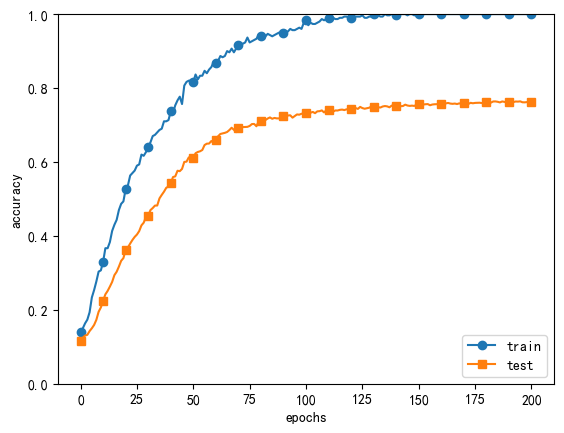

In [14]:
import os
import sys

sys.path.append(os.pardir)  # 为了导入父目录的文件而进行的设定
import numpy as np
import matplotlib.pyplot as plt
from dataset.mnist import load_mnist
from common.multi_layer_net import MultiLayerNet
from common.optimizer import SGD

(x_train, t_train), (x_test, t_test) = load_mnist(normalize=True)

# 为了再现过拟合，减少学习数据
x_train = x_train[:300]
t_train = t_train[:300]

# weight decay（权值衰减）的设定 =======================
weight_decay_lambda = 0 # 不使用权值衰减的情况
# weight_decay_lambda = 0.1
# ====================================================

network = MultiLayerNet(input_size=784, hidden_size_list=[100, 100, 100, 100, 100, 100], output_size=10,
                        weight_decay_lambda=weight_decay_lambda)
optimizer = SGD(lr=0.01)

max_epochs = 201
train_size = x_train.shape[0]
batch_size = 100

train_loss_list = []
train_acc_list = []
test_acc_list = []

iter_per_epoch = max(train_size / batch_size, 1)
epoch_cnt = 0

for i in range(1000000000):
    batch_mask = np.random.choice(train_size, batch_size)
    x_batch = x_train[batch_mask]
    t_batch = t_train[batch_mask]

    grads = network.gradient(x_batch, t_batch)
    optimizer.update(network.params, grads)

    if i % iter_per_epoch == 0:
        train_acc = network.accuracy(x_train, t_train)
        test_acc = network.accuracy(x_test, t_test)
        train_acc_list.append(train_acc)
        test_acc_list.append(test_acc)

        print(f"轮次: {epoch_cnt:3d} | 训练准确率: {train_acc:.4f} | 测试准确率: {test_acc:.4f}")

        epoch_cnt += 1
        if epoch_cnt >= max_epochs:
            break


# 3.绘制图形==========
markers = {'train': 'o', 'test': 's'}
x = np.arange(max_epochs)
plt.plot(x, train_acc_list, marker='o', label='train', markevery=10)
plt.plot(x, test_acc_list, marker='s', label='test', markevery=10)
plt.xlabel("epochs")
plt.ylabel("accuracy")
plt.ylim(0, 1.0)
plt.legend(loc='lower right')
plt.show()

过了 100 个 epoch 左右后，用训练数据测量到的识别精度几乎都为100%。但是，对于测试数据，离100%的识别精度还有较大的差距。如此大的识别精度差距，是只拟合了训练数据的结果。从图中可知，模型对训练时没有使用的一般数据（测试数据）拟合得不是很好。

## 权值衰减 
权值衰减是一直以来经常被使用的一种抑制过拟合的方法。该方法通过在学习的过程中对大的权重进行惩罚，来抑制过拟合。很多过拟合原本就是因为权重参数取值过大才发生的。

复习一下，神经网络的学习目的是减小损失函数的值。这时，例如为损失函数加上权重的平方范数（L2范数）。这样一来，就可以抑制权重变大。用符号表示的话，如果将权重记为$\boldsymbol{W}$，L2范数的权值衰减就是$\frac{1}{2}\lambda\boldsymbol{W}^2$，然后将这个$\frac{1}{2}\lambda\boldsymbol{W}^2$加到损失函数上。这里，$\lambda$是控制正则化强度的超参数。$\lambda$设置得越大，对大的权重施加的惩罚就越重。此外，$\frac{1}{2}\lambda\boldsymbol{W}^2$开头的$\frac{1}{2}$是用于将$\frac{1}{2}\lambda\boldsymbol{W}^2$的求导结果变成$\lambda\boldsymbol{W}$的调整用常量。

对于所有权重，权值衰减方法都会为损失函数加上$\frac{1}{2}\lambda\boldsymbol{W}^2$。因此，在求权重梯度的计算中，要为之前的误差反向传播法的结果加上正则化项的导数$\lambda\boldsymbol{W}$。


L2范数相当于各个元素的平方和。用数学式表示的话，假设有权重$\boldsymbol{W} = (w_1, w_2, \dots, w_n)$，则L2范数可用$\sqrt{w_1^2 + w_2^2 + \dots + w_n^2}$计算出来。除了L2范数，还有L1范数、$\text{L}_\infty$范数等。L1范数是各个元素的绝对值之和，相当于$|w_1| + |w_2| + \dots + |w_n|$。$\text{L}_\infty$范数也称为Max范数，相当于各个元素的绝对值中最大的那一个。L2范数、L1范数、$\text{L}_\infty$范数都可以用作正则化项，它们各有各的特点，不过这里我们要实现的是比较常用的L2范数。

现在我们来进行实验。对于刚刚进行的实验，应用$\lambda = 0.1$的权值衰减，结果如图所示。

轮次:   0 | 训练准确率: 0.1267 | 测试准确率: 0.0913
轮次:   1 | 训练准确率: 0.1333 | 测试准确率: 0.1044
轮次:   2 | 训练准确率: 0.1400 | 测试准确率: 0.1154
轮次:   3 | 训练准确率: 0.1633 | 测试准确率: 0.1249
轮次:   4 | 训练准确率: 0.1767 | 测试准确率: 0.1349
轮次:   5 | 训练准确率: 0.1900 | 测试准确率: 0.1429
轮次:   6 | 训练准确率: 0.1900 | 测试准确率: 0.1517
轮次:   7 | 训练准确率: 0.2067 | 测试准确率: 0.1597
轮次:   8 | 训练准确率: 0.2000 | 测试准确率: 0.1669
轮次:   9 | 训练准确率: 0.2033 | 测试准确率: 0.1722
轮次:  10 | 训练准确率: 0.2467 | 测试准确率: 0.1876
轮次:  11 | 训练准确率: 0.2533 | 测试准确率: 0.1936
轮次:  12 | 训练准确率: 0.2767 | 测试准确率: 0.2106
轮次:  13 | 训练准确率: 0.2900 | 测试准确率: 0.2182
轮次:  14 | 训练准确率: 0.3000 | 测试准确率: 0.2358
轮次:  15 | 训练准确率: 0.3200 | 测试准确率: 0.2404
轮次:  16 | 训练准确率: 0.3367 | 测试准确率: 0.2388
轮次:  17 | 训练准确率: 0.3800 | 测试准确率: 0.2718
轮次:  18 | 训练准确率: 0.4367 | 测试准确率: 0.3065
轮次:  19 | 训练准确率: 0.4433 | 测试准确率: 0.3204
轮次:  20 | 训练准确率: 0.5133 | 测试准确率: 0.3602
轮次:  21 | 训练准确率: 0.5500 | 测试准确率: 0.3811
轮次:  22 | 训练准确率: 0.5700 | 测试准确率: 0.3928
轮次:  23 | 训练准确率: 0.5200 | 测试准确率: 0.3713
轮次:  24 | 训练准确率: 0.6067 | 测试准确率: 0.4271


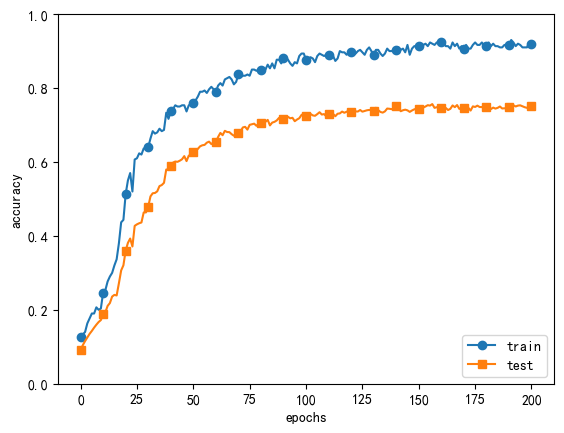

In [15]:
import os
import sys

sys.path.append(os.pardir)  # 为了导入父目录的文件而进行的设定
import numpy as np
import matplotlib.pyplot as plt
from dataset.mnist import load_mnist
from common.multi_layer_net import MultiLayerNet
from common.optimizer import SGD

(x_train, t_train), (x_test, t_test) = load_mnist(normalize=True)

# 为了再现过拟合，减少学习数据
x_train = x_train[:300]
t_train = t_train[:300]

# weight decay（权值衰减）的设定 =======================
# weight_decay_lambda = 0 # 不使用权值衰减的情况
weight_decay_lambda = 0.1
# ====================================================

network = MultiLayerNet(input_size=784, hidden_size_list=[100, 100, 100, 100, 100, 100], output_size=10,
                        weight_decay_lambda=weight_decay_lambda)
optimizer = SGD(lr=0.01)

max_epochs = 201
train_size = x_train.shape[0]
batch_size = 100

train_loss_list = []
train_acc_list = []
test_acc_list = []

iter_per_epoch = max(train_size / batch_size, 1)
epoch_cnt = 0

for i in range(1000000000):
    batch_mask = np.random.choice(train_size, batch_size)
    x_batch = x_train[batch_mask]
    t_batch = t_train[batch_mask]

    grads = network.gradient(x_batch, t_batch)
    optimizer.update(network.params, grads)

    if i % iter_per_epoch == 0:
        train_acc = network.accuracy(x_train, t_train)
        test_acc = network.accuracy(x_test, t_test)
        train_acc_list.append(train_acc)
        test_acc_list.append(test_acc)

        print(f"轮次: {epoch_cnt:3d} | 训练准确率: {train_acc:.4f} | 测试准确率: {test_acc:.4f}")

        epoch_cnt += 1
        if epoch_cnt >= max_epochs:
            break


# 3.绘制图形==========
markers = {'train': 'o', 'test': 's'}
x = np.arange(max_epochs)
plt.plot(x, train_acc_list, marker='o', label='train', markevery=10)
plt.plot(x, test_acc_list, marker='s', label='test', markevery=10)
plt.xlabel("epochs")
plt.ylabel("accuracy")
plt.ylim(0, 1.0)
plt.legend(loc='lower right')
plt.show()

图所示，虽然训练数据的识别精度和测试数据的识别精度之间有差距，但是与没有使用权值衰减的图6-20的结果相比，差距变小了。这说明过拟合受到了抑制。此外，还要注意，训练数据的识别精度没有达到100%（1.0）。

## Dropout
作为抑制过拟合的方法，前面我们介绍了为损失函数加上权重的L2范数的权值衰减方法。该方法可以简单地实现，在某种程度上能够抑制过拟合。但是，如果网络的模型变得很复杂，只用权值衰减就难以应对了。在这种情况下，我们经常会使用Dropout方法。

Dropout是一种在学习的过程中随机删除神经元的方法。训练时，随机选出隐藏层的神经元，然后将其删除。被删除的神经元不再进行信号的传递，如图所示。训练时，每传递一次数据，就会随机选择要删除的神经元。然后，测试时，虽然会传递所有的神经元信号，但是对于各个神经元的输出，要乘上训练时的删除比例后再输出。

<img src="./fig/dropout.png" alt="dropout" style="display: block; margin: 0 auto;">

In [16]:
class Dropout:
    def __init__(self, dropout_ratio=0.5):
        self.dropout_ratio = dropout_ratio  #  dropout比例，默认0.5（即随机丢弃50%的神经元）
        self.mask = None  # 用于存储dropout的掩码（标记哪些神经元被保留）

    def forward(self, x, train_flg=True):
        if train_flg:  # 训练模式
            # 生成与输入x形状相同的随机数组，值在0~1之间
            # 通过与dropout_ratio比较，生成布尔掩码（大于比例的保留，即True）
            self.mask = np.random.rand(*x.shape) > self.dropout_ratio
            return x * self.mask  # 用掩码过滤输入，被丢弃的神经元输出变为0
        else:  # 测试模式
            # 不丢弃任何神经元，而是将所有输出乘以(1 - dropout_ratio)进行缩放
            # 这是为了保证训练和测试时的输出期望一致
            return x * (1.0 - self.dropout_ratio)
        
    def backward(self, dout):
        return dout * self.mask  # 梯度传播时，同样应用前向时的掩码

这里的要点是，每次正向传播时，``self.mask``中都会以``False``的形式保存要删除的神经元。``self.mask``会随机生成和x形状相同的数组，并将值比``dropout_ratio``大的元素设为``True``。反向传播时的行为和ReLU相同。也就是说，正向传播时传递了信号的神经元，反向传播时按原样传递信号；正向传播时没有传递信号的神经元，反向传播时信号将停在那里。

train loss:2.5098174230574104
=== epoch:1, train acc:0.10666666666666667, test acc:0.1533 ===
train loss:2.280548501181442
train loss:2.384895772870472
train loss:2.3401001513226034
=== epoch:2, train acc:0.19666666666666666, test acc:0.1866 ===
train loss:2.263106205769332
train loss:2.27224849383374
train loss:2.2683000337886416
=== epoch:3, train acc:0.23333333333333334, test acc:0.2036 ===
train loss:2.2305575167375604
train loss:2.211354653117431
train loss:2.2330605253302966
=== epoch:4, train acc:0.2866666666666667, test acc:0.2214 ===
train loss:2.152844179456723
train loss:2.1380626905679065
train loss:2.1352821510037017
=== epoch:5, train acc:0.31, test acc:0.2348 ===
train loss:2.172797743242128
train loss:2.107784292808165
train loss:2.1293994378509713
=== epoch:6, train acc:0.37666666666666665, test acc:0.2607 ===
train loss:2.0519277445788093
train loss:1.9880715370639448
train loss:2.1258894335426266
=== epoch:7, train acc:0.4066666666666667, test acc:0.2859 ===
train lo

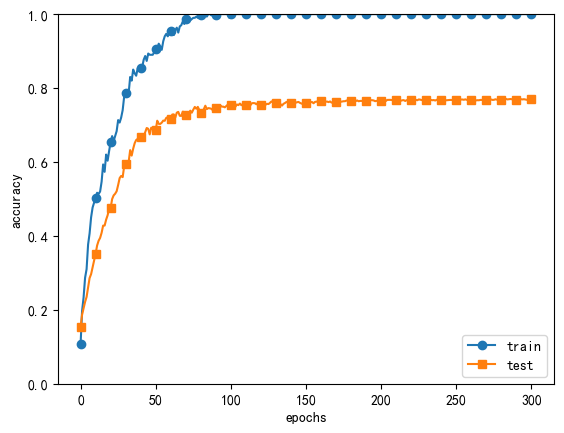

In [17]:
import os
import sys
sys.path.append(os.pardir)  # 为了导入父目录的文件而进行的设定
import numpy as np
import matplotlib.pyplot as plt
from dataset.mnist import load_mnist
from common.multi_layer_net_extend import MultiLayerNetExtend
from common.trainer import Trainer

(x_train, t_train), (x_test, t_test) = load_mnist(normalize=True)

# 为了再现过拟合，减少学习数据
x_train = x_train[:300]
t_train = t_train[:300]

# 设定是否使用Dropuout，以及比例 ========================
use_dropout = False  # 不使用Dropout的情况下为False
# ====================================================

network = MultiLayerNetExtend(input_size=784, hidden_size_list=[100, 100, 100, 100, 100, 100],
                              output_size=10, use_dropout=use_dropout)
trainer = Trainer(network, x_train, t_train, x_test, t_test,
                  epochs=301, mini_batch_size=100,
                  optimizer='sgd', optimizer_param={'lr': 0.01}, verbose=True) # verbose=True表示打印训练过程
trainer.train() # 开始训练，训练结果保存在trainer对象中

train_acc_list, test_acc_list = trainer.train_acc_list, trainer.test_acc_list

# 绘制图形==========
markers = {'train': 'o', 'test': 's'}
x = np.arange(len(train_acc_list))
plt.plot(x, train_acc_list, marker='o', label='train', markevery=10)
plt.plot(x, test_acc_list, marker='s', label='test', markevery=10)
plt.xlabel("epochs")
plt.ylabel("accuracy")
plt.ylim(0, 1.0)
plt.legend(loc='lower right')
plt.show()

train loss:2.3135808579775587
=== epoch:1, train acc:0.08333333333333333, test acc:0.0934 ===
train loss:2.296772573505434
train loss:2.2820223142132496
train loss:2.327082665350356
=== epoch:2, train acc:0.08333333333333333, test acc:0.0914 ===
train loss:2.304074273123464
train loss:2.315875243958563
train loss:2.3034524093600335
=== epoch:3, train acc:0.08333333333333333, test acc:0.0917 ===
train loss:2.3025250752586763
train loss:2.3046844528181323
train loss:2.2946101905138407
=== epoch:4, train acc:0.08333333333333333, test acc:0.0915 ===
train loss:2.3132129644181383
train loss:2.313840612792598
train loss:2.2821334746957866
=== epoch:5, train acc:0.08666666666666667, test acc:0.0905 ===
train loss:2.311356612361881
train loss:2.2867051974504995
train loss:2.2830235888915786
=== epoch:6, train acc:0.08666666666666667, test acc:0.0929 ===
train loss:2.307020126530756
train loss:2.30288179718896
train loss:2.293451283213134
=== epoch:7, train acc:0.08666666666666667, test acc:0.0

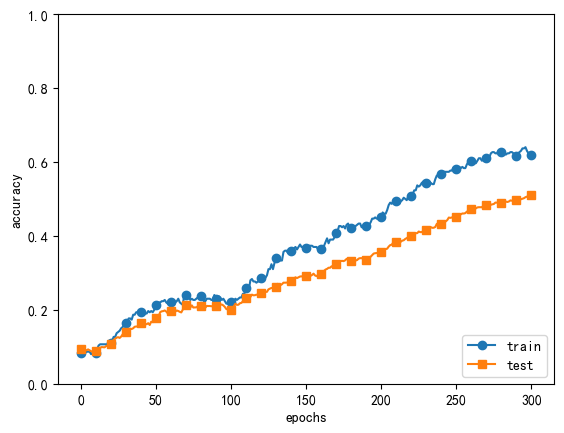

In [18]:
import os
import sys
sys.path.append(os.pardir)  # 为了导入父目录的文件而进行的设定
import numpy as np
import matplotlib.pyplot as plt
from dataset.mnist import load_mnist
from common.multi_layer_net_extend import MultiLayerNetExtend
from common.trainer import Trainer

(x_train, t_train), (x_test, t_test) = load_mnist(normalize=True)

# 为了再现过拟合，减少学习数据
x_train = x_train[:300]
t_train = t_train[:300]

# 设定是否使用Dropuout，以及比例 ========================
use_dropout = True  # 不使用Dropout的情况下为False
dropout_ratio = 0.2
# ====================================================

network = MultiLayerNetExtend(input_size=784, hidden_size_list=[100, 100, 100, 100, 100, 100],
                              output_size=10, use_dropout=use_dropout, dropout_ration=dropout_ratio)
trainer = Trainer(network, x_train, t_train, x_test, t_test,
                  epochs=301, mini_batch_size=100,
                  optimizer='sgd', optimizer_param={'lr': 0.01}, verbose=True) # verbose=True表示打印训练过程
trainer.train()

train_acc_list, test_acc_list = trainer.train_acc_list, trainer.test_acc_list

# 绘制图形==========
markers = {'train': 'o', 'test': 's'}
x = np.arange(len(train_acc_list))
plt.plot(x, train_acc_list, marker='o', label='train', markevery=10)
plt.plot(x, test_acc_list, marker='s', label='test', markevery=10)
plt.xlabel("epochs")
plt.ylabel("accuracy")
plt.ylim(0, 1.0)
plt.legend(loc='lower right')
plt.show()

图中，通过使用Dropout，训练数据和测试数据的识别精度的差距变小了。并且，训练数据也没有到达100%的识别精度。像这样，通过使用Dropout，即便是表现力强的网络，也可以抑制过拟合。

机器学习中经常使用集成学习。所谓集成学习，就是让多个模型单独进行学习，推理时再取多个模型的输出的平均值。用神经网络的语境来说，比如，准备 5个结构相同（或者类似）的网络，分别进行学习，测试时，以这 5个网络的输出的平均值作为答案。实验告诉我们，通过进行集成学习，神经网络的识别精度可以提高好几个百分点。这个集成学习与 Dropout有密切的关系。这是因为可以将 Dropout理解为，通过在学习过程中随机删除神经元，从而每一次都让不同的模型进行学习。并且，推理时，通过对神经元的输出乘以删除比例（比如，0.5等），可以取得模型的平均值。也就是说，可以理解成，Dropout将集成学习的效果（模拟地）通过一个网络实现了。

## 超参数的验证
神经网络中，除了权重和偏置等参数，超参数(hyper - parameter)也经常出现。这里所说的超参数是指，比如各层的神经元数量、batch大小、参数更新时的学习率或权值衰减等。如果这些超参数没有设置合适的值，模型的性能就会很差。虽然超参数的取值非常重要，但是在决定超参数的过程中一般会伴随很多的试错。本节将介绍尽可能高效地寻找超参数的值的方法。

### 验证数据
之前我们使用的数据集分成了训练数据和测试数据，训练数据用于学习，测试数据用于评估泛化能力。由此，就可以评估是否只过度拟合了训练数据(是否发生了过拟合)，以及泛化能力如何等。

下面我们要对超参数设置各种各样的值以进行验证。这里要注意的是，不能使用测试数据评估超参数的性能。这一点非常重要，但也容易被忽视。

为什么不能用测试数据评估超参数的性能呢？这是因为如果使用测试数据调整超参数，超参数的值会对测试数据发生过拟合。换句话说，用测试数据确认超参数的值的“好坏”，就会导致超参数的值被调整为只拟合测试数据。这样的话，可能就会得到不能拟合其他数据、泛化能力低的模型。

因此，调整超参数时，必须使用超参数专用的确认数据。用于调整超参数的数据，一般称为验证数据(validation data)。我们使用这个验证数据来评估超参数的好坏。

训练数据用于参数(权重和偏置)的学习，验证数据用于超参数的性能评估。为了确认泛化能力，要在最后使用(比较理想的是只用一次)测试数据。

根据不同的数据集，有的会事先分成训练数据、验证数据、测试数据三部分，有的只分成训练数据和测试数据两部分，有的则不进行分割。在这种情况下，用户需要自行进行分割。如果是MNIST数据集，获得验证数据的最简单的方法就是从训练数据中事先分割20%作为验证数据，代码如下所示。

In [19]:
import os
import sys
sys.path.append(os.pardir)  # 为了导入父目录的文件而进行的设定
import numpy as np
from dataset.mnist import load_mnist
from common.util import shuffle_dataset

(x_train, t_train), (x_test, t_test) = load_mnist(normalize=True, one_hot_label=True)

# 打乱训练数据
x_train, t_train = shuffle_dataset(x_train, t_train)

# 分割验证数据
validation_rate = 0.2
validation_num = int(x_train.shape[0] * validation_rate)
x_val = x_train[:validation_num]# 取前validation_num个作为验证数据
t_val = t_train[:validation_num]# 取前validation_num个作为验证数据
x_train = x_train[validation_num:]# 剩下的作为训练数据
t_train = t_train[validation_num:]# 剩下的作为训练数据

这里，分割训练数据前，先打乱了输入数据和教师标签。这是因为数据集的数据可能存在偏向（比如，数据从“0”到“10”按顺序排列等）。这里使用的``shuffle_dataset``函数利用了``np.random.shuffle``，在``common/util.py``中有它的实现。

## 超参数的最优化
进行超参数的最优化时，逐渐缩小超参数的“好值”的存在范围非常重要。所谓逐渐缩小范围，是指一开始先大致设定一个范围，从这个范围中随机选出一个超参数（采样），用这个采样到的值进行识别精度的评估；然后，多次重复该操作，观察识别精度的结果，根据这个结果缩小超参数的“好值”的范围。通过重复这一操作，就可以逐渐确定超参数的合适范围。

有报告显示，在进行神经网络的超参数的最优化时，与网格搜索等有规律的搜索相比，随机采样的搜索方式效果更好。这是因为在多个超参数中，各个超参数对最终的识别精度的影响程度不同。

超参数的范围只要“大致地指定”就可以了。所谓“大致地指定”，是指像$0.001(10^{-3})$到$1000(10^3)$这样，以“10的阶乘”的尺度指定范围（也表述为“用对数尺度(log scale)指定”）。

在超参数的最优化中，要注意的是深度学习需要很长时间（比如，几天或几周）。因此，在超参数的搜索中，需要尽早放弃那些不符合逻辑的超参数。于是，在超参数的最优化中，减少学习的epoch，缩短一次评估所需的时间是一个不错的办法。

以上就是超参数的最优化的内容，简单归纳一下，如下所示。

- **步骤0**：设定超参数的范围。
- **步骤1**：从设定的超参数范围中随机采样。
- **步骤2**：使用步骤1中采样到的超参数的值进行学习，通过验证数据评估识别精度（但是要将epoch设置得很小）。
- **步骤3**：重复步骤1和步骤2（100次等），根据它们的识别精度的结果，缩小超参数的范围。

反复进行上述操作，不断缩小超参数的范围，在缩小到一定程度时，从该范围中选出一个超参数的值。这就是进行超参数的最优化的一种方法。

这里介绍的超参数的最优化方法是实践性的方法。不过，这个方法与其说是科学方法，倒不如说有些实践者的经验的感觉。在超参数的最优化中，如果需要更精炼的方法，可以使用贝叶斯最优化（Bayesian optimization）。贝叶斯最优化运用以贝叶斯定理为中心的数学理论，能够更加严密、高效地进行最优化。

验证准确率: 0.2500 | 学习率: 0.001140 | 权重衰减: 0.000002
验证准确率: 0.1900 | 学习率: 0.000574 | 权重衰减: 0.000004
验证准确率: 0.1000 | 学习率: 0.000035 | 权重衰减: 0.000084
验证准确率: 0.0700 | 学习率: 0.000005 | 权重衰减: 0.000002
验证准确率: 0.1700 | 学习率: 0.000052 | 权重衰减: 0.000002
验证准确率: 0.2600 | 学习率: 0.001601 | 权重衰减: 0.000006
验证准确率: 0.0700 | 学习率: 0.000002 | 权重衰减: 0.000000
验证准确率: 0.6500 | 学习率: 0.004760 | 权重衰减: 0.000001
验证准确率: 0.0700 | 学习率: 0.000003 | 权重衰减: 0.000000
验证准确率: 0.4900 | 学习率: 0.003044 | 权重衰减: 0.000005
验证准确率: 0.2100 | 学习率: 0.000692 | 权重衰减: 0.000000
验证准确率: 0.0600 | 学习率: 0.000008 | 权重衰减: 0.000000
验证准确率: 0.0500 | 学习率: 0.000063 | 权重衰减: 0.000001
验证准确率: 0.1000 | 学习率: 0.000011 | 权重衰减: 0.000078
验证准确率: 0.1200 | 学习率: 0.000020 | 权重衰减: 0.000034
验证准确率: 0.7200 | 学习率: 0.006283 | 权重衰减: 0.000000
验证准确率: 0.2400 | 学习率: 0.000619 | 权重衰减: 0.000000
验证准确率: 0.0900 | 学习率: 0.000048 | 权重衰减: 0.000000
验证准确率: 0.5300 | 学习率: 0.004245 | 权重衰减: 0.000046
验证准确率: 0.1000 | 学习率: 0.000007 | 权重衰减: 0.000023
验证准确率: 0.1100 | 学习率: 0.000162 | 权重衰减: 0.000084
验证准确率: 0.0600

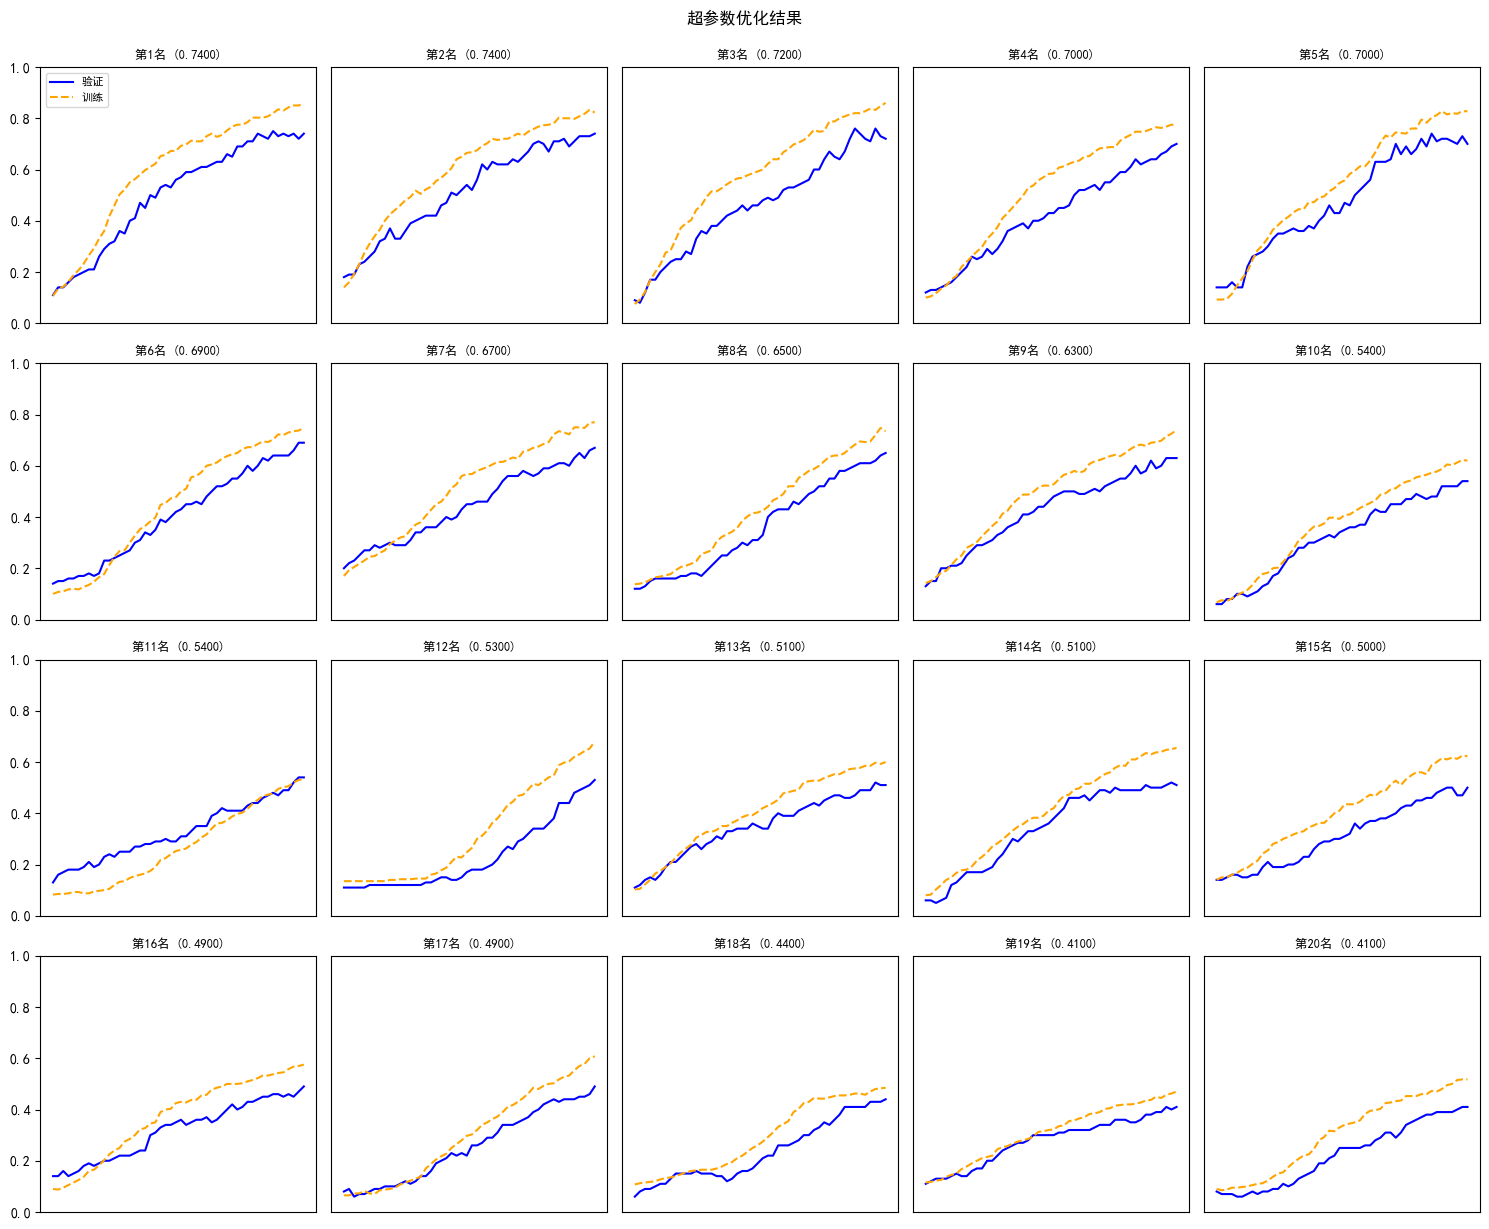

In [20]:
import sys, os
sys.path.append(os.pardir)  # 为了导入父目录的文件而进行的设定
import numpy as np
import matplotlib.pyplot as plt
from dataset.mnist import load_mnist
from common.multi_layer_net import MultiLayerNet
from common.util import shuffle_dataset
from common.trainer import Trainer

(x_train, t_train), (x_test, t_test) = load_mnist(normalize=True)

# 为了实现高速化，减少训练数据
x_train = x_train[:500]
t_train = t_train[:500]

# 分割验证数据
validation_rate = 0.20
validation_num = int(x_train.shape[0] * validation_rate)
x_train, t_train = shuffle_dataset(x_train, t_train)
x_val = x_train[:validation_num]
t_val = t_train[:validation_num]
x_train = x_train[validation_num:]
t_train = t_train[validation_num:]


def __train(lr, weight_decay, epocs=50):
    network = MultiLayerNet(input_size=784, hidden_size_list=[100, 100, 100, 100, 100, 100],
                            output_size=10, weight_decay_lambda=weight_decay)
    trainer = Trainer(network, x_train, t_train, x_val, t_val,
                      epochs=epocs, mini_batch_size=100,
                      optimizer='sgd', optimizer_param={'lr': lr}, verbose=False)
    trainer.train() # 开始训练，训练结果保存在trainer对象中

    return trainer.test_acc_list, trainer.train_acc_list


# 超参数的随机搜索======================================
optimization_trial = 100
results_val = {}
results_train = {}
for _ in range(optimization_trial):
    # 指定搜索的超参数的范围===============
    weight_decay = 10 ** np.random.uniform(-8, -4) # 权重衰减，指数均匀分布
    lr = 10 ** np.random.uniform(-6, -2) # 学习率，指数均匀分布
    # ================================================

    val_acc_list, train_acc_list = __train(lr, weight_decay)
    print(f"验证准确率: {val_acc_list[-1]:.4f} | 学习率: {lr:.6f} | 权重衰减: {weight_decay:.6f}")
    key = "学习率:" + str(lr) + ", 权重衰减:" + str(weight_decay)
    results_val[key] = val_acc_list
    results_train[key] = train_acc_list

# 绘制图形========================================================
print("=========== 超参数优化结果 ===========")
graph_draw_num = 20
col_num = 5
row_num = int(np.ceil(graph_draw_num / col_num))

# 创建一个大画布
plt.figure(figsize=(15, 3*row_num))

i = 0
# 按验证准确率排序
for key, val_acc_list in sorted(results_val.items(), key=lambda x:x[1][-1], reverse=True):
    # 子图位置
    plt.subplot(row_num, col_num, i+1)
    
    # 绘制曲线
    x = np.arange(len(val_acc_list))
    plt.plot(x, val_acc_list, label='验证', color='blue')
    plt.plot(x, results_train[key], "--", label='训练', color='orange')
    
    # 标题显示排名和准确率
    val_acc = val_acc_list[-1]
    print(f"最佳第{i+1}名 (验证准确率: {val_acc:.4f}) | {key}")
    plt.title(f"第{i+1}名 ({val_acc:.4f})", fontsize=9)
    
    # 坐标轴设置
    plt.ylim(0.0, 1.0)
    plt.xticks([])  # 隐藏x轴刻度
    if i % col_num != 0:  # 只保留第一列的y轴刻度
        plt.yticks([])
    
    # 只在第一个图显示图例
    if i == 0:
        plt.legend(fontsize=8)
    
    i += 1
    if i >= graph_draw_num:
        break

# 调整布局
plt.tight_layout()
plt.suptitle('超参数优化结果', y=1.02, fontsize=12)
plt.show()

从这个结果可以看出，学习率在0.001到0.01、权值衰减系数在$10^{-8}$到$10^{-6}$之间时，学习可以顺利进行。像这样，观察可以使学习顺利进行的超参数的范围，从而缩小值的范围。然后，在这个缩小的范围中重复相同的操作。这样就能缩小到合适的超参数的存在范围，然后在某个阶段，选择一个最终的超参数的值。

## 小结
- 参数的更新方法，除了SGD之外，还有Momentum、AdaGrad、Adam等方法。
- 权重初始值的赋值方法对进行正确的学习非常重要。
- 作为权重初始值，Xavier初始值、He初始值等比较有效。
- 通过使用Batch Normalization，可以加速学习，并且对初始值变得健壮。
- 抑制过拟合的正则化技术有权值衰减、Dropout等。
- 逐渐缩小“好值”存在的范围是搜索超参数的一个有效方法。